# FactoryMind AI — Leakage-Safe RUL Feature Engineering

This notebook develops a focused, interpretable feature strategy for NASA C-MAPSS **FD001**. It does not train a regression model or use the official test set for feature selection.

The central rule is causal: a predictor for cycle \(t\) may use only information observed for the same engine through cycle \(t\).

## 1. Load and Validate FD001

Each row is a sequential operating-cycle observation. `unit_id` identifies the trajectory, `cycle` provides order, operational settings describe the regime, sensors are candidate measurements, and RUL columns are retrospective targets—not predictors.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (9, 5), "axes.titlesize": 13, "axes.labelsize": 11})
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

DATA_DIR = Path("../data/raw")
if not DATA_DIR.exists():
    DATA_DIR = Path("data/raw")
TRAIN_PATH = DATA_DIR / "train_FD001.txt"
assert TRAIN_PATH.exists(), f"Missing required training file: {TRAIN_PATH}"

raw_train = pd.read_csv(TRAIN_PATH, sep=r"\s+", header=None)
columns = (["unit_id", "cycle"]
           + [f"operational_setting_{i}" for i in range(1, 4)]
           + [f"sensor_{i}" for i in range(1, 22)])
assert raw_train.shape[1] == len(columns) == 26
train = raw_train.copy()
train.columns = columns
train["raw_rul"] = train.groupby("unit_id")["cycle"].transform("max") - train["cycle"]

assert train.shape[0] == 20_631
assert train["unit_id"].nunique() == 100
assert (train["raw_rul"] >= 0).all()
assert (train.loc[train.groupby("unit_id")["cycle"].idxmax(), "raw_rul"] == 0).all()
assert train.groupby("unit_id")["cycle"].apply(lambda x: x.is_monotonic_increasing).all()

identifier_columns = ["unit_id"]
ordering_columns = ["cycle"]
setting_columns = [f"operational_setting_{i}" for i in range(1, 4)]
sensor_columns = [f"sensor_{i}" for i in range(1, 22)]
target_columns = ["raw_rul"]
print(f"Validated {len(train):,} rows across {train['unit_id'].nunique()} ordered unit trajectories.")
display(train.head())

Validated 20,631 rows across 100 ordered unit trajectories.


,unit_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,raw_rul
0,1,1,-0.0007,-0.0004,100.0000,518.6700,641.8200,"1,589.7000","1,400.6000",14.6200,21.6100,554.3600,"2,388.0600","9,046.1900",1.3000,47.4700,521.6600,"2,388.0200","8,138.6200",8.4195,0.0300,392,2388,100.0000,39.0600,23.4190,191
1,1,2,0.0019,-0.0003,100.0000,518.6700,642.1500,"1,591.8200","1,403.1400",14.6200,21.6100,553.7500,"2,388.0400","9,044.0700",1.3000,47.4900,522.2800,"2,388.0700","8,131.4900",8.4318,0.0300,392,2388,100.0000,39.0000,23.4236,190
2,1,3,-0.0043,0.0003,100.0000,518.6700,642.3500,"1,587.9900","1,404.2000",14.6200,21.6100,554.2600,"2,388.0800","9,052.9400",1.3000,47.2700,522.4200,"2,388.0300","8,133.2300",8.4178,0.0300,390,2388,100.0000,38.9500,23.3442,189
3,1,4,0.0007,0.0000,100.0000,518.6700,642.3500,"1,582.7900","1,401.8700",14.6200,21.6100,554.4500,"2,388.1100","9,049.4800",1.3000,47.1300,522.8600,"2,388.0800","8,133.8300",8.3682,0.0300,392,2388,100.0000,38.8800,23.3739,188
4,1,5,-0.0019,-0.0002,100.0000,518.6700,642.3700,"1,582.8500","1,406.2200",14.6200,21.6100,554.0000,"2,388.0600","9,055.1500",1.3000,47.2800,522.1900,"2,388.0400","8,133.8000",8.4294,0.0300,393,2388,100.0000,38.9000,23.4044,187


## 2. Candidate Sensor Set

Notebook 06 established that sensors 1, 5, 10, 16, 18, and 19 are exact constants. They cannot distinguish observations in FD001 and are excluded from candidate predictors.

Sensor 6 is investigated separately. Sensor 17 remains available: low cardinality alone is not sufficient evidence for removal.

Target-correlation ranking on the complete dataset is **not** used as the sole selection rule. Doing so would let target information from units later assigned to validation influence feature design, making future performance estimates optimistic. Here, exact/near constancy controls exclusions; all other sensors remain raw candidates. A small temporal subset is chosen using combined evidence from variance, representative trajectories, and engineering relevance documented in EDA.

In [2]:
constant_sensors = ["sensor_1", "sensor_5", "sensor_10", "sensor_16", "sensor_18", "sensor_19"]

sensor_6_audit = pd.Series({
    "unique_values": train["sensor_6"].nunique(),
    "dominant_value_share_pct": train["sensor_6"].value_counts(normalize=True).iloc[0] * 100,
    "standard_deviation": train["sensor_6"].std(),
    "observed_range": train["sensor_6"].max() - train["sensor_6"].min(),
    "raw_rul_correlation_for_context_only": train["sensor_6"].corr(train["raw_rul"]),
})
display(sensor_6_audit.to_frame("sensor_6"))
print(train["sensor_6"].value_counts().rename("observations").to_frame())

# Sensor 6 takes only two values 0.01 apart and is at its dominant value in >98% of rows.
# Exclusion is based on its near-constant measurement behavior, not target correlation.
near_constant_excluded = ["sensor_6"]
retained_sensors = [s for s in sensor_columns if s not in constant_sensors + near_constant_excluded]
assert "sensor_17" in retained_sensors
print(f"Retained sensors ({len(retained_sensors)}):", retained_sensors)
print("Excluded constant sensors:", constant_sensors)
print("Excluded near-constant sensor:", near_constant_excluded)

,sensor_6
unique_values,2.0000
dominant_value_share_pct,98.0321
standard_deviation,0.0014
observed_range,0.0100
raw_rul_correlation_for_context_only,-0.1283


          observations
sensor_6              
21.6100          20225
21.6000            406
Retained sensors (14): ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
Excluded constant sensors: ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Excluded near-constant sensor: ['sensor_6']


## 3. Provisional Capped RUL Target

The raw target exactly represents retrospective remaining cycles. A provisional piecewise target caps early healthy life at 125 cycles:

\[
\text{capped RUL} = \min(\text{raw RUL}, 125)
\]

This is a modeling assumption, not a universal optimum. It reduces pressure to distinguish exact long-horizon lifetimes that may be operationally indistinguishable. Notebook 08 must evaluate it using unit-separated validation.

,value
provisional_cap_cycles,125.0000
observations_affected,"8,031.0000"
percentage_affected,38.9269


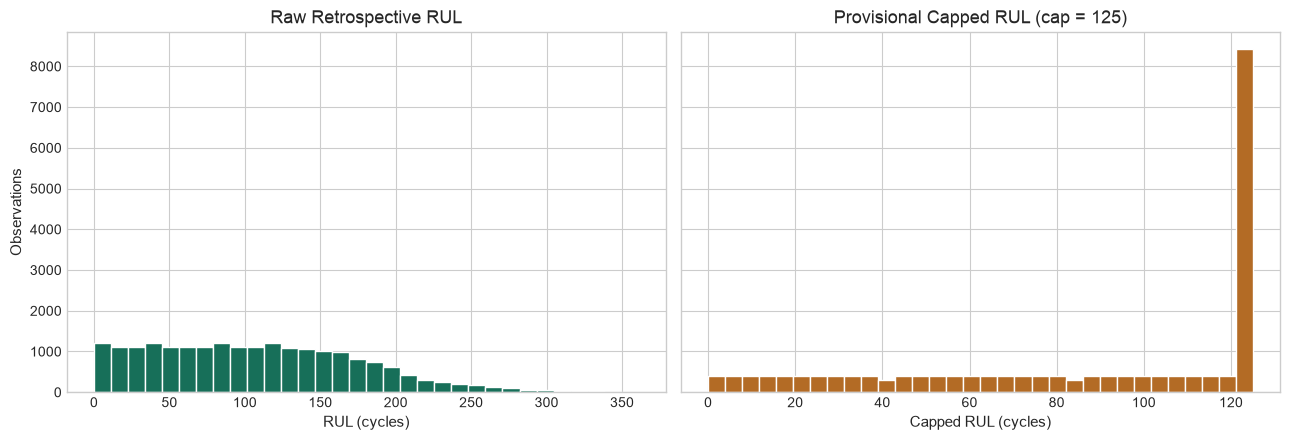

In [3]:
RUL_CAP = 125
train["capped_rul"] = train["raw_rul"].clip(upper=RUL_CAP)
target_columns = ["raw_rul", "capped_rul"]

assert (train["capped_rul"] <= RUL_CAP).all()
assert (train["capped_rul"] <= train["raw_rul"]).all()

capped_mask = train["raw_rul"] > RUL_CAP
capping_summary = pd.Series({
    "provisional_cap_cycles": RUL_CAP,
    "observations_affected": int(capped_mask.sum()),
    "percentage_affected": capped_mask.mean() * 100,
})
display(capping_summary.to_frame("value"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
axes[0].hist(train["raw_rul"], bins=32, color="#176f59", edgecolor="white")
axes[0].set(title="Raw Retrospective RUL", xlabel="RUL (cycles)", ylabel="Observations")
axes[1].hist(train["capped_rul"], bins=32, color="#b36b25", edgecolor="white")
axes[1].set(title=f"Provisional Capped RUL (cap = {RUL_CAP})", xlabel="Capped RUL (cycles)")
plt.tight_layout()
plt.show()

## 4. Leakage-Safe Temporal Features

Temporal features are built for six focused sensors with meaningful variation and consistent degradation evidence: 4, 7, 11, 12, 15, and 21. Every operation is grouped by `unit_id` after chronological sorting.

Created families:

- current raw value;
- lag 1 and lag 5 via **positive** shifts;
- trailing 5-cycle mean;
- trailing 5-cycle standard deviation with population variance and `min_periods=1`;
- one-cycle delta calculated from the current value minus lag 1.

There are no centered windows, negative shifts, future cycles, lifetime-derived predictors, or target-derived predictors.

In [4]:
temporal_base_sensors = ["sensor_4", "sensor_7", "sensor_11", "sensor_12", "sensor_15", "sensor_21"]
assert set(temporal_base_sensors).issubset(retained_sensors)

features = train.sort_values(["unit_id", "cycle"]).copy()
grouped = features.groupby("unit_id", sort=False)
engineered_features = []

for sensor in temporal_base_sensors:
    lag_1 = f"{sensor}_lag_1"
    lag_5 = f"{sensor}_lag_5"
    rolling_mean = f"{sensor}_rolling_mean_5"
    rolling_std = f"{sensor}_rolling_std_5"
    delta_1 = f"{sensor}_delta_1"

    features[lag_1] = grouped[sensor].shift(1)
    features[lag_5] = grouped[sensor].shift(5)
    features[rolling_mean] = grouped[sensor].transform(
        lambda values: values.rolling(window=5, min_periods=1).mean()
    )
    features[rolling_std] = grouped[sensor].transform(
        lambda values: values.rolling(window=5, min_periods=1).std(ddof=0)
    )
    features[delta_1] = features[sensor] - features[lag_1]
    engineered_features.extend([lag_1, lag_5, rolling_mean, rolling_std, delta_1])

assert len(features) == len(train)
assert features["unit_id"].nunique() == train["unit_id"].nunique()
assert len(engineered_features) == 30
assert features.groupby("unit_id").head(1)[[f"{s}_lag_1" for s in temporal_base_sensors]].isna().all().all()
assert features.groupby("unit_id").head(5)[[f"{s}_lag_5" for s in temporal_base_sensors]].isna().all().all()

print(f"Created {len(engineered_features)} trailing temporal features without filtering rows.")
display(features[identifier_columns + ordering_columns + temporal_base_sensors[:2] + engineered_features[:10] + target_columns].head(8))

Created 30 trailing temporal features without filtering rows.


,unit_id,cycle,sensor_4,sensor_7,sensor_4_lag_1,sensor_4_lag_5,sensor_4_rolling_mean_5,sensor_4_rolling_std_5,sensor_4_delta_1,sensor_7_lag_1,sensor_7_lag_5,sensor_7_rolling_mean_5,sensor_7_rolling_std_5,sensor_7_delta_1,raw_rul,capped_rul
0,1,1,"1,400.6000",554.3600,NaN,NaN,"1,400.6000",0.0000,NaN,NaN,NaN,554.3600,0.0000,NaN,191,125
1,1,2,"1,403.1400",553.7500,"1,400.6000",NaN,"1,401.8700",1.2700,2.5400,554.3600,NaN,554.0550,0.3050,-0.6100,190,125
2,1,3,"1,404.2000",554.2600,"1,403.1400",NaN,"1,402.6467",1.5105,1.0600,553.7500,NaN,554.1233,0.2671,0.5100,189,125
3,1,4,"1,401.8700",554.4500,"1,404.2000",NaN,"1,402.4525",1.3507,-2.3300,554.2600,NaN,554.2050,0.2712,0.1900,188,125
4,1,5,"1,406.2200",554.0000,"1,401.8700",NaN,"1,403.2060",1.9315,4.3500,554.4500,NaN,554.1640,0.2560,-0.4500,187,125
5,1,6,"1,398.3700",554.6700,"1,406.2200","1,400.6000","1,402.7600",2.6174,-7.8500,554.0000,554.3600,554.2260,0.3244,0.6700,186,125
6,1,7,"1,397.7700",554.3400,"1,398.3700","1,403.1400","1,401.6860",3.2632,-0.6000,554.6700,553.7500,554.3440,0.2204,-0.3300,185,125
7,1,8,"1,400.9700",553.8500,"1,397.7700","1,404.2000","1,401.0400",3.0116,3.2000,554.3400,554.2600,554.2620,0.2988,-0.4900,184,125


## 5. Early-Cycle Missing Values

Lag features are mathematically undefined before enough history exists. Those missing values convey sequence position and are retained rather than globally filled or dropping early observations.

Rolling features use available trailing history through `min_periods=1`; their early values are therefore causal. In notebook 08, any imputation for lag/delta features must be fitted **inside each training fold**. A missingness indicator may also be evaluated.

In [5]:
temporal_missingness = pd.DataFrame({
    "missing_count": features[engineered_features].isna().sum(),
    "missing_percentage": features[engineered_features].isna().mean() * 100,
}).sort_values("missing_count", ascending=False)
display(temporal_missingness)

missing_by_family = pd.Series({
    "lag_1": int(features.filter(regex=r"_lag_1$").isna().sum().sum()),
    "lag_5": int(features.filter(regex=r"_lag_5$").isna().sum().sum()),
    "rolling_mean_5": int(features.filter(regex=r"_rolling_mean_5$").isna().sum().sum()),
    "rolling_std_5": int(features.filter(regex=r"_rolling_std_5$").isna().sum().sum()),
    "delta_1": int(features.filter(regex=r"_delta_1$").isna().sum().sum()),
})
display(missing_by_family.to_frame("missing_cells"))

,missing_count,missing_percentage
sensor_21_lag_5,500,2.4235
sensor_15_lag_5,500,2.4235
sensor_7_lag_5,500,2.4235
sensor_12_lag_5,500,2.4235
sensor_4_lag_5,500,2.4235
sensor_11_lag_5,500,2.4235
sensor_4_lag_1,100,0.4847
sensor_11_delta_1,100,0.4847
sensor_21_lag_1,100,0.4847
sensor_15_delta_1,100,0.4847


,missing_cells
lag_1,600
lag_5,3000
rolling_mean_5,0
rolling_std_5,0
delta_1,600


## 6. Model-Independent Feature Evidence

The following analysis is descriptive and uses training data only. Correlations help compare raw and engineered representations, but they do not constitute feature selection or performance estimates. Unit-separated modeling is still required.

In [6]:
focused_evidence_features = []
for sensor in temporal_base_sensors:
    focused_evidence_features.extend([
        sensor,
        f"{sensor}_rolling_mean_5",
        f"{sensor}_rolling_std_5",
        f"{sensor}_delta_1",
    ])

feature_summary = features[focused_evidence_features].describe().T
feature_summary["missing_count"] = features[focused_evidence_features].isna().sum()
display(feature_summary)

correlation_evidence = features[focused_evidence_features + ["capped_rul"]].corr()["capped_rul"].drop("capped_rul")
correlation_evidence = correlation_evidence.to_frame("correlation_with_capped_rul")
correlation_evidence["absolute_correlation"] = correlation_evidence["correlation_with_capped_rul"].abs()
display(correlation_evidence.sort_values("absolute_correlation", ascending=False).head(18))

,count,mean,std,min,25%,50%,75%,max,missing_count
sensor_4,"20,631.0000","1,408.9338",9.0006,"1,382.2500","1,402.3600","1,408.0400","1,414.5550","1,441.4900",0
sensor_4_rolling_mean_5,"20,631.0000","1,408.6709",8.0324,"1,387.3800","1,402.6330","1,407.7120","1,413.4830","1,432.9840",0
sensor_4_rolling_std_5,"20,631.0000",3.3691,1.2505,0.0000,2.4862,3.3085,4.1789,10.7900,0
sensor_4_delta_1,"20,531.0000",0.1385,5.6994,-22.3500,-3.7100,0.1100,4.0100,25.0100,100
sensor_7,"20,631.0000",553.3677,0.8851,549.8500,552.8100,553.4400,554.0100,556.0600,0
sensor_7_rolling_mean_5,"20,631.0000",553.3925,0.7878,550.8100,552.9340,553.4600,553.9960,555.3700,0
sensor_7_rolling_std_5,"20,631.0000",0.3387,0.1298,0.0000,0.2472,0.3299,0.4236,1.1026,0
sensor_7_delta_1,"20,531.0000",-0.0128,0.5773,-2.2300,-0.4000,-0.0200,0.3700,2.7000,100
sensor_11,"20,631.0000",47.5412,0.2671,46.8500,47.3500,47.5100,47.7000,48.5300,0
sensor_11_rolling_mean_5,"20,631.0000",47.5332,0.2447,46.9300,47.3480,47.5100,47.6760,48.2740,0


,correlation_with_capped_rul,absolute_correlation
sensor_4_rolling_mean_5,-0.8157,0.8157
sensor_11_rolling_mean_5,-0.8140,0.8140
sensor_15_rolling_mean_5,-0.8104,0.8104
sensor_21_rolling_mean_5,0.8045,0.8045
sensor_12_rolling_mean_5,0.7934,0.7934
sensor_7_rolling_mean_5,0.7926,0.7926
sensor_11,-0.7752,0.7752
sensor_4,-0.7572,0.7572
sensor_12,0.7489,0.7489
sensor_7,0.7330,0.7330


,raw_correlation,rolling_mean_5_correlation,absolute_change
sensor,,,
sensor_4,-0.7572,-0.8157,0.0586
sensor_7,0.7330,0.7926,0.0596
sensor_11,-0.7752,-0.8140,0.0388
sensor_12,0.7489,0.7934,0.0445
sensor_15,-0.7209,-0.8104,0.0896
sensor_21,0.7073,0.8045,0.0971


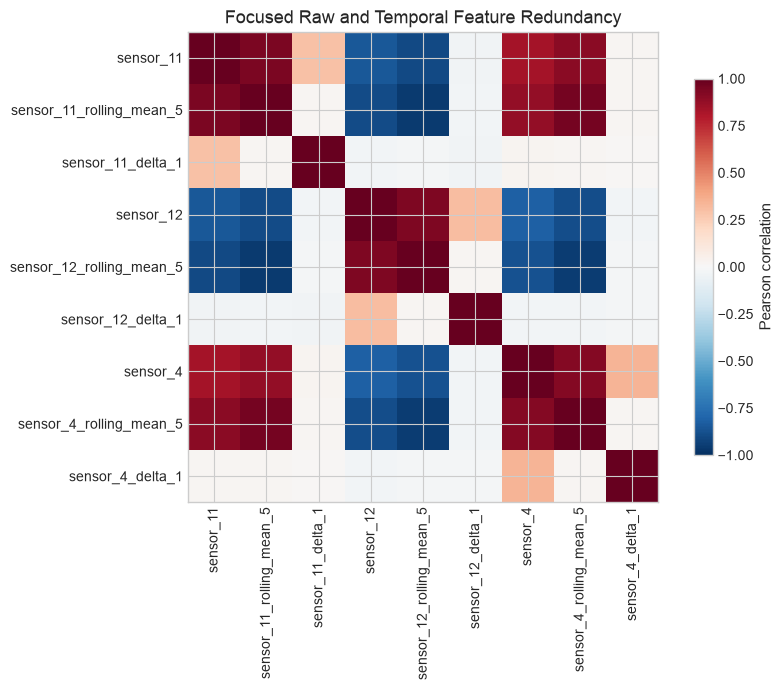

In [7]:
raw_vs_rolling = []
for sensor in temporal_base_sensors:
    raw_corr = features[sensor].corr(features["capped_rul"])
    rolling_corr = features[f"{sensor}_rolling_mean_5"].corr(features["capped_rul"])
    raw_vs_rolling.append({
        "sensor": sensor,
        "raw_correlation": raw_corr,
        "rolling_mean_5_correlation": rolling_corr,
        "absolute_change": abs(rolling_corr) - abs(raw_corr),
    })
raw_vs_rolling = pd.DataFrame(raw_vs_rolling).set_index("sensor")
display(raw_vs_rolling)

plot_subset = [
    "sensor_11", "sensor_11_rolling_mean_5", "sensor_11_delta_1",
    "sensor_12", "sensor_12_rolling_mean_5", "sensor_12_delta_1",
    "sensor_4", "sensor_4_rolling_mean_5", "sensor_4_delta_1",
]
redundancy_corr = features[plot_subset].corr()
fig, ax = plt.subplots(figsize=(9, 7))
image = ax.imshow(redundancy_corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(plot_subset)), plot_subset, rotation=90)
ax.set_yticks(range(len(plot_subset)), plot_subset)
ax.set_title("Focused Raw and Temporal Feature Redundancy")
fig.colorbar(image, ax=ax, label="Pearson correlation", shrink=0.8)
plt.tight_layout()
plt.show()

Rolling means are intentionally highly related to their raw sensors, but reduce short-term noise and generally strengthen the global capped-RUL association. Deltas provide distinct short-horizon change information with weaker linear target correlation; their usefulness may emerge through nonlinear models or aggregation. This redundancy should be assessed inside future unit-level folds rather than pruned from full-data correlations.

## 7. Representative Trajectory Comparison

A median-lifetime engine is selected mechanically. The plots compare a raw measurement with its trailing mean and one-cycle delta. The rolling mean does not invent future information; at each cycle it uses at most the current and four previous readings.

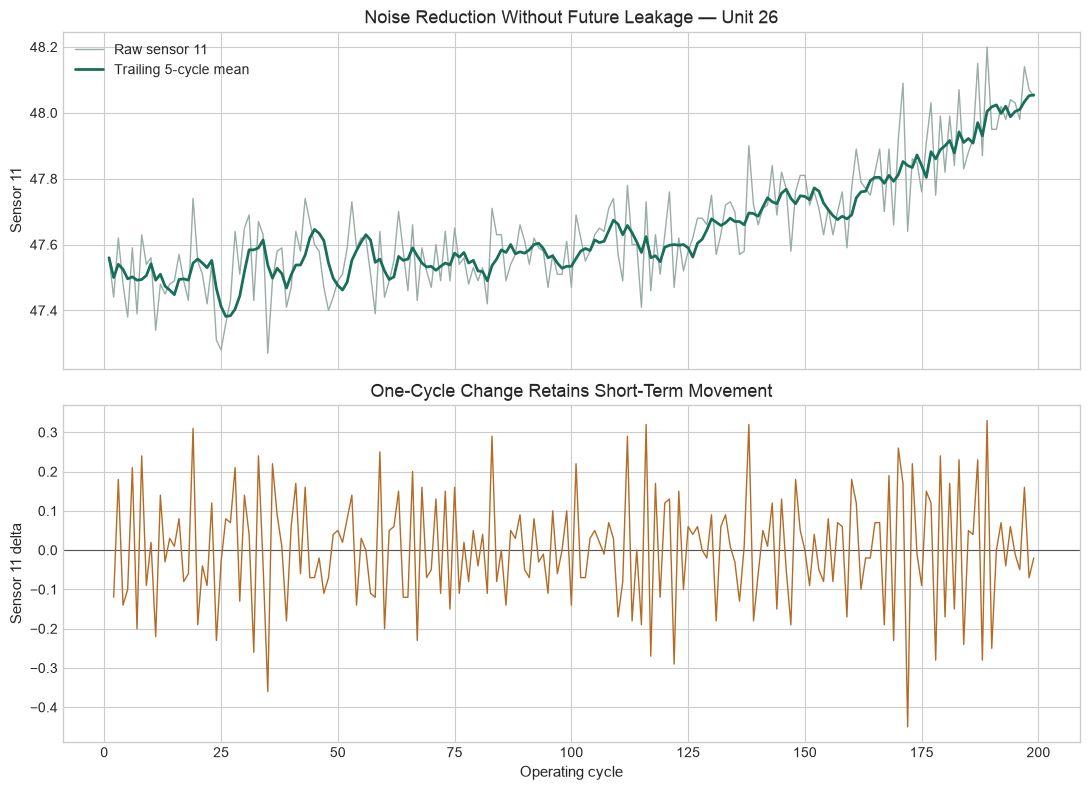

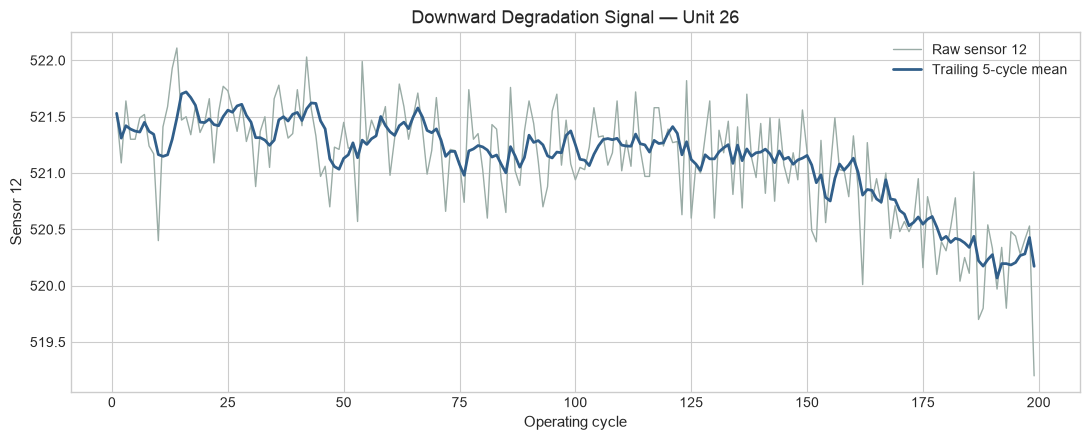

In [8]:
lifetimes = features.groupby("unit_id")["cycle"].max()
median_unit = int((lifetimes - lifetimes.median()).abs().idxmin())
trajectory = features.loc[features["unit_id"].eq(median_unit)]

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
axes[0].plot(trajectory["cycle"], trajectory["sensor_11"], color="#9aaca6", linewidth=1, label="Raw sensor 11")
axes[0].plot(trajectory["cycle"], trajectory["sensor_11_rolling_mean_5"], color="#176f59", linewidth=2, label="Trailing 5-cycle mean")
axes[0].set(title=f"Noise Reduction Without Future Leakage — Unit {median_unit}", ylabel="Sensor 11")
axes[0].legend()
axes[1].axhline(0, color="#555555", linewidth=0.8)
axes[1].plot(trajectory["cycle"], trajectory["sensor_11_delta_1"], color="#b36b25", linewidth=1)
axes[1].set(title="One-Cycle Change Retains Short-Term Movement", xlabel="Operating cycle", ylabel="Sensor 11 delta")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(trajectory["cycle"], trajectory["sensor_12"], color="#9aaca6", linewidth=1, label="Raw sensor 12")
ax.plot(trajectory["cycle"], trajectory["sensor_12_rolling_mean_5"], color="#315f8a", linewidth=2, label="Trailing 5-cycle mean")
ax.set(title=f"Downward Degradation Signal — Unit {median_unit}", xlabel="Operating cycle", ylabel="Sensor 12")
ax.legend()
plt.tight_layout()
plt.show()

For the representative unit, trailing means make the longer-term degradation direction easier to see while retaining late-life movement. One-cycle deltas remain noisy, which supports testing them rather than assuming they will improve prediction.

## 8. Future Unit-Aware Validation Design

Notebook 08 should use **GroupKFold** (for example, five folds) with `unit_id` as the group. Every cycle from one engine must remain entirely within one fold. GroupShuffleSplit is a reasonable alternative for a single reproducible validation partition.

Ordinary row-level splitting would leak unit-specific baselines, nearby cycles, and overlapping rolling histories into both training and validation. Preprocessing—including imputation, scaling, and any data-driven feature selection—must be contained in a pipeline and fitted separately inside each training fold.

The official FD001 test sequences and `RUL_FD001.txt` remain reserved for later endpoint evaluation. They were not loaded or used in this notebook.

## 9. Recommended Feature Contract for Notebook 08

In [9]:
raw_predictor_columns = (
    ["cycle", "operational_setting_1", "operational_setting_2"]
    + retained_sensors
)
# operational_setting_3 is excluded because it is exactly constant in FD001.
engineered_predictor_columns = engineered_features.copy()
proposed_predictors = raw_predictor_columns + engineered_predictor_columns
excluded_columns = (
    identifier_columns
    + target_columns
    + ["operational_setting_3"]
    + constant_sensors
    + near_constant_excluded
)

feature_contract = pd.Series({
    "identifier_columns": identifier_columns,
    "target_columns": target_columns,
    "raw_predictor_count": len(raw_predictor_columns),
    "engineered_predictor_count": len(engineered_predictor_columns),
    "total_proposed_predictors": len(proposed_predictors),
    "excluded_columns": excluded_columns,
})
display(feature_contract.to_frame("definition"))

assert not set(target_columns).intersection(proposed_predictors)
assert not set(identifier_columns).intersection(proposed_predictors)
assert not set(constant_sensors).intersection(proposed_predictors)
assert "sensor_6" not in proposed_predictors
assert "sensor_17" in proposed_predictors
assert len(proposed_predictors) == len(set(proposed_predictors))
print("Raw predictors:", raw_predictor_columns)
print("Engineered predictors:", engineered_predictor_columns)

,definition
identifier_columns,[unit_id]
target_columns,"[raw_rul, capped_rul]"
raw_predictor_count,17
engineered_predictor_count,30
total_proposed_predictors,47
excluded_columns,"[unit_id, raw_rul, capped_rul, operational_set..."


Raw predictors: ['cycle', 'operational_setting_1', 'operational_setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
Engineered predictors: ['sensor_4_lag_1', 'sensor_4_lag_5', 'sensor_4_rolling_mean_5', 'sensor_4_rolling_std_5', 'sensor_4_delta_1', 'sensor_7_lag_1', 'sensor_7_lag_5', 'sensor_7_rolling_mean_5', 'sensor_7_rolling_std_5', 'sensor_7_delta_1', 'sensor_11_lag_1', 'sensor_11_lag_5', 'sensor_11_rolling_mean_5', 'sensor_11_rolling_std_5', 'sensor_11_delta_1', 'sensor_12_lag_1', 'sensor_12_lag_5', 'sensor_12_rolling_mean_5', 'sensor_12_rolling_std_5', 'sensor_12_delta_1', 'sensor_15_lag_1', 'sensor_15_lag_5', 'sensor_15_rolling_mean_5', 'sensor_15_rolling_std_5', 'sensor_15_delta_1', 'sensor_21_lag_1', 'sensor_21_lag_5', 'sensor_21_rolling_mean_5', 'sensor_21_rolling_std_5', 'sensor_21_delta_1']


## 10. Methodological Notes

- FD001 is simulated C-MAPSS data; production claims require validation on representative real fleet data.
- RUL labels are retrospective targets. True remaining lifetime is unknown during live operation.
- Same-engine observations are temporally dependent and are not independent rows.
- Temporal feature engineering must preserve ordering and unit boundaries.
- The 125-cycle cap is provisional and must be compared against alternatives using unit-level validation.
- Official test labels cannot influence feature selection, preprocessing, imputation, or hyperparameters.
- FD001's effectively single operating condition makes normalization simpler than multi-condition subsets; the strategy cannot be transferred blindly to FD002–FD004.

## 11. Validation

In [10]:
# Static guardrails complement the behavioral unit-boundary assertions above.
forbidden_name_tokens = ("lead_", "future_", "next_cycle", "final_lifetime", "raw_rul", "capped_rul")
assert not any(any(token in name for token in forbidden_name_tokens) for name in proposed_predictors)
assert len(features) == 20_631
assert features["unit_id"].nunique() == 100
assert (features["raw_rul"] >= 0).all()
assert (features["capped_rul"] <= RUL_CAP).all()
assert features.groupby("unit_id")["cycle"].apply(lambda x: x.is_monotonic_increasing).all()

validation = pd.Series({
    "row_count_preserved": len(features) == len(train),
    "unit_count_preserved": features["unit_id"].nunique() == train["unit_id"].nunique(),
    "nonnegative_raw_rul": bool((features["raw_rul"] >= 0).all()),
    "capped_rul_within_cap": bool((features["capped_rul"] <= RUL_CAP).all()),
    "unit_boundaries_verified_for_lags": True,
    "targets_absent_from_predictors": not set(target_columns).intersection(proposed_predictors),
    "constant_sensors_absent": not set(constant_sensors).intersection(proposed_predictors),
    "future_looking_operations_intentionally_used": False,
    "official_test_labels_used": False,
    "model_trained": False,
})
display(validation.to_frame("result"))
assert validation.drop(["future_looking_operations_intentionally_used", "official_test_labels_used", "model_trained"]).all()
assert not validation[["future_looking_operations_intentionally_used", "official_test_labels_used", "model_trained"]].any()

,result
row_count_preserved,True
unit_count_preserved,True
nonnegative_raw_rul,True
capped_rul_within_cap,True
unit_boundaries_verified_for_lags,True
targets_absent_from_predictors,True
constant_sensors_absent,True
future_looking_operations_intentionally_used,False
official_test_labels_used,False
model_trained,False


## RUL Feature-Engineering Conclusions

- **Target:** carry both raw RUL and a provisional 125-cycle capped RUL into controlled comparison. Capping affects 8,031 observations (38.93%).
- **Retained sensors:** 2, 3, 4, 7, 8, 9, 11, 12, 13, 14, 15, 17, 20, and 21.
- **Excluded sensors:** exact constants 1, 5, 10, 16, 18, and 19; near-constant sensor 6, which takes only two values 0.01 apart and is at its dominant value in over 98% of rows.
- **Sensor 17:** retained despite low cardinality because it varies materially and low cardinality alone is not a defensible exclusion rule.
- **Temporal features:** positive lags at 1 and 5 cycles, trailing 5-cycle means and standard deviations, and one-cycle deltas for sensors 4, 7, 11, 12, 15, and 21.
- **Missingness:** retain natural early-cycle lag/delta NaNs. Any imputation and optional missing indicators must be fitted inside training folds in notebook 08.
- **Proposed contract:** 17 raw predictors plus 30 engineered predictors, for **47 total predictors**. Identifiers and both targets remain outside the predictor matrix.
- **Evidence:** trailing means expose smoother degradation directions and generally strengthen global target association, while deltas add distinct but noisy local-change information. This remains exploratory, not a performance claim.
- **Validation design:** use unit-aware GroupKFold with all preprocessing inside each fold. Keep the official FD001 test set and its RUL labels untouched until endpoint evaluation.

**Recommended next step:** notebook 08 should compare baseline RUL regressors, raw versus capped targets, and incremental feature families under GroupKFold—without creating production artifacts until the methodology is selected.